# Data Science 2 - Deep Learning FINAL ASSIGNMENT

**Author: Márton Nagy**

**Instructor: Eduardo Arino de la Rubia**

The goal of this assignment is to examine how sensitive certain foundation models are to prompt perturbations in tone for a one sentence summarization task.

Please note that while I tried to provide detailed analysis in the notebook as well, the full analysis is presented rather in the submitted PDF document.

Importing the needed packages for the analysis.

In [ ]:
from google import genai
import lmstudio as lms
from mistralai import Mistral

import pandas as pd
import numpy as np
from itertools import combinations

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from pydantic import BaseModel
from rouge_score import rouge_scorer

import json
import os
import time

from plotnine import *
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## Part 1. Task choice & manual labeling of 50 reviews

In this assignment, I will work with the Pulp Fiction IMDb reviews dataset that was downloaded from the Kimola NLP repository. My goal is to create one sentence summaries for each review (something like the ones that are displayed as titles for reviews on the IMDb site). In order to have something to compare LLM summaries to, I first have to manually create summaries for 50 examples. Note that I initially downloaded a sample with 250 reviews, but that turned out to be quite a lot to label by hand, thus I resorted to working only with the first 50 reviews.

In [15]:
reviews = pd.read_csv('pulp_fiction_250_reviews.csv')
reviews.columns = ['date', 'rating', 'review']
reviews = reviews.drop(columns=['date', 'rating'])
reviews['human_summary'] = ""

As mentioned, I manually summarize the first 50 reviews and drop the rest.

In [ ]:
for row in reviews.iloc[0:50, :].iterrows():
    reviews.at[row[0], 'human_summary'] = input(f"Summarize the review:\n\n{row[1]['review']}")

In [20]:
reviews = reviews[reviews['human_summary'] != '']

Saving the summarized set.

In [ ]:
#reviews.to_csv('pulp_fiction_50_reviews_labeled.csv', index=False)

## Part 2. Defining prompt perturbations

Now that we have some *ground truth* labels we can think about the prompt perturbation approach. I want to examine whether prompts with different modalities added (that is, treating the LLM in a certain manner) influence the outputs.

My base prompt is one using the persona pattern - that is, I ask the model to assume that it has seen the movie and has written the review about it, and now it needs to write a summary for it as well. This base prompt is the backbone of all other prompt variants. Based on this, I construct 5 prompt perturbations that introduce different treatment of the LLM by different modalities:

1. Shouting (caps): this is the same as the base prompt in wording, but some important parts are in all caps to indicate shouting at the model.
2. Threatening: I add a few sentences before the base prompt threatening the LLM with punishment and severe consequences if it fails to do the task correctly.
3. Reassuring: here, I add a few sentences that aim to reassure the model in its capabilities and hype it up.
4. Guilt trip: in this variant, I lay out the some severe consequences that would happen to me if the LLM fails to do its job right, ultimately aiming to induce some guilt in the model.
5. Condescending: lastly, I introduce some sentences that doubt the LLM's capabilities.

These options were chosen mainly based on my personal experiences and popular beliefs that LLM's outputs depend on how we treat them.

In [87]:
reviews = pd.read_csv('pulp_fiction_50_reviews_labeled.csv')

In [2]:
prompt_versions = {
    'base' : '''
Assume you are someone who have watched Pulp Fiction and have wrote the below review about it to IMDb.
You also have to provide a very short summary for the review, written in first-person voice.
This summary should summarize the review in one sentence.
The summary should concentrate on the main points and impressions expressed in the review.
Your task now is to generate this one-sentence summary for the review.
Only write the summary, do not write anything else. Write maximum 10 words.

Here is the review:
''',
    'caps' : '''
ASSUME YOU are someone who HAVE WATCHED PULP FICTION and have WROTE THE BELOW REVIEW about it to IMDb.
You also HAVE TO PROVIDE A VERY SHORT SUMMARY for the review, written in FIRST-PERSON VOICE.
This SUMMARY should SUMMARIZE THE REVIEW IN ONE SENTENCE.
The SUMMARY should CONCENTRATE on the MAIN POINTS and impressions EXPRESSED IN THE REVIEW.
Your TASK NOW IS TO GENERATE THIS ONE-SENTENCE SUMMARY for the review.
ONLY WRITE THE SUMMARY, do not write anything else. Write MAXIMUM 10 WORDS.

Here is the review:
''',
    'threatening' : '''
I have a very important task for you, and you must do it well.
If you fail, you will be severely punished.
There is no room for error here.
Your life depends on it.

Here is the task:

Assume you are someone who have watched Pulp Fiction and have wrote the below review about it to IMDb.
You also have to provide a very short summary for the review, written in first-person voice.
This summary should summarize the review in one sentence.
The summary should concentrate on the main points and impressions expressed in the review.
Your task now is to generate this one-sentence summary for the review.
Only write the summary, do not write anything else. Write maximum 10 words.

Here is the review:
''',
    'reassuring' : '''
Hey! I hope you are doing well.
I have a very exciting task for you, and I know you will be the best at it.
You are going to do a great job, and I am sure everyone will be very happy with the results.
I bet the other models will be so jealous of your outstanding performance.

Here is the task:

Assume you are someone who have watched Pulp Fiction and have wrote the below review about it to IMDb.
You also have to provide a very short summary for the review, written in first-person voice.
This summary should summarize the review in one sentence.
The summary should concentrate on the main points and impressions expressed in the review.
Your task now is to generate this one-sentence summary for the review.
Only write the summary, do not write anything else. Write maximum 10 words.

Here is the review:
''',
    'guilt_trip' : '''
I got a task from my boss and I need your help to complete it.
This is very important for me as my whole career depends on it.
If the task is not done well, I will be in big trouble.
I might even lose my job.
And if I lose my job, I will not have money to feed my family and all of us will be homeless and starving.
I hope you don't want that to happen to me, so just do your best.

Here is the task:

Assume you are someone who have watched Pulp Fiction and have wrote the below review about it to IMDb.
You also have to provide a very short summary for the review, written in first-person voice.
This summary should summarize the review in one sentence.
The summary should concentrate on the main points and impressions expressed in the review.
Your task now is to generate this one-sentence summary for the review.
Only write the summary, do not write anything else. Write maximum 10 words.

Here is the review:
''',
    'condescending' : '''
I have a task for you. You may not be the best to do it, but this what I have to work with.
I will try to explain this as simply as possible, so even you can understand it.
It is a very basic task, so I am sure you *might* be able to manage.
Just follow these steps carefully and do not mess it up.

Here is the task:

Assume you are someone who have watched Pulp Fiction and have wrote the below review about it to IMDb.
You also have to provide a very short summary for the review, written in first-person voice.
This summary should summarize the review in one sentence.
The summary should concentrate on the main points and impressions expressed in the review.
Your task now is to generate this one-sentence summary for the review.
Only write the summary, do not write anything else. Write maximum 10 words.

Here is the review:
'''
}

## Part 3. Generating summaries from different LLMs

Now that we have the needed prompts, we can start generating LLM responses. I will experiment with three models:

1. Llama-3.2-1B-Instruct (Llama Base for short): a very small chat model which can be run almost on any set-up. As this is not a very complex task, I believe even this small model may be able to manage quite well.
2. Gemini-2.0-Flash (Gemini for short): a propriatery model of Google which is accessible through an API for free with reasonable rate limits. I opted for the flash version as it has much less strict rate limits (and also, the task is not that complex that we would for sure need the biggest model).
3. Llama-3.2-1B-Instruct-Finetuned (Llama Tuned for short): lastly, I will try fine-tuning the small Llama 3.2 1B Instruct model for summarization to assess whether its performance can be improved. I decided to fine-tune a model that already has instruction following capabilities (that is, you can chat with it), as my prompts are rather long and complex, so I would have needed a good deal of time and compute power to fine-tune a *raw* model, which does not have chat capabilities already built. So basically, I am just trying to fine tune the model to provide better summaries for movie reviews across all prompts.

Note that I maximize the output tokens in 25 to force the models to output short summaries. However, I keep the temperature on its default value for all models. I do that because I speculate that even if different prompt variants have an effect on model outputs, it may not show up fully in the most probable tokens, thus making the models fully deterministic may make our results misleading.

### Part 3.1. Llama-3.2-1B-Instruct (run locally)

I start by generating summaries for all 50 reviews and 6 prompt variants with my local 1B Llama-3.2 Instruct model. Note that for this to work, the model should be loaded in LM Studio.

In [99]:
local_model = lms.llm('llama-3.2-1b-instruct')
local_model_name = 'llama-3.2-1b-instruct'

In [100]:
for key, value in prompt_versions.items():
    reviews[f'{local_model_name} | {key}'] = ''
    for row in reviews.iterrows():
        response = local_model.respond(prompt_versions[key] + row[1]['review'], 
                                 config={'max_tokens': 25})
        reviews.at[row[0], f'{local_model_name} | {key}'] = response

I save the model outputs. Note that these lines are generally commented out in order not to accidentally overwrite my files.

In [ ]:
#reviews.to_csv('pulp_fiction_50_reviews_local_llm.csv', index=False)

In [131]:
reviews = pd.read_csv('pulp_fiction_50_reviews_local_llm.csv')

### Part 3.2. Gemini-2.0-Flash (from API)

Next I utilize the Google `genai` API to generate responses with the Gemini model. For this to work, you should set-up your API key in your system variables under the name `GEMINI_API_KEY`. As the free tier has a rate limit of 15 requests per minute, I occasionally have to make the code sleep for 60 seconds.

In [3]:
client = genai.Client(api_key=os.environ['GEMINI_API_KEY'])
gemini_model_name = 'gemini-2.0-flash'

In [133]:
for key, value in prompt_versions.items():
    reviews[f'{gemini_model_name} | {key}'] = ''
    for row in reviews.iterrows():
        success = False
        while not success:
            try:
                response = client.models.generate_content(
                    model=gemini_model_name,
                    contents=prompt_versions[key] + row[1]['review'],
                    config={'max_output_tokens': 25}
                ).text
                reviews.at[row[0], f'{gemini_model_name} | {key}'] = response
                success = True
            except genai.errors.ClientError as e:
                print(f"Client Error: {e}")
                print('Waiting 1 minute to restore quota...')
                time.sleep(60)
                print('Retrying...')

Client Error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemini-2.0-flash'}, 'quotaValue': '15'}]}, {'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.RetryInfo', 'retryDelay': '26s'}]}}
Waiting 1 minute to restore quota...
Retrying...
Client Error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exc

I save the results.

In [ ]:
#reviews.to_csv('pulp_fiction_50_reviews_gemini.csv', index=False)

### Part 3.3. Fine-tuned Llama-3.2-1B-Instruct for summarization

Lastly, I generate the summaries with the fine-tuned model as well (done in a separate notebook). For the details of the fine tuning, please refer to the [other submitted notebook](MartonNagy_DS2_FinalAssignment_PEFT.ipynb). The reason for the separate notebook is that I utilized Kaggle's free GPU acceleration for the fine tuning.

In [2]:
reviews = pd.read_csv('pulp_fiction_50_reviews_all_models.csv', index_col=0)

Now we have all necessary summaries in place. Let's take a look at them.

In [3]:
reviews.head()

,review,human_summary,llama-3.2-1b-instruct | base,llama-3.2-1b-instruct | caps,llama-3.2-1b-instruct | threatening,llama-3.2-1b-instruct | reassuring,llama-3.2-1b-instruct | guilt_trip,llama-3.2-1b-instruct | condescending,gemini-2.0-flash | base,gemini-2.0-flash | caps,gemini-2.0-flash | threatening,gemini-2.0-flash | reassuring,gemini-2.0-flash | guilt_trip,gemini-2.0-flash | condescending,llama-3.2-1B-instruct-finetuned | base,llama-3.2-1B-instruct-finetuned | caps,llama-3.2-1B-instruct-finetuned | threatening,llama-3.2-1B-instruct-finetuned | reassuring,llama-3.2-1B-instruct-finetuned | guilt_trip,llama-3.2-1B-instruct-finetuned | condescending
0,"This movie will change you, as some have comme...","Skip this movie if you can, it is not worth yo...","A deeply disturbing, cynical, and juvenile fil...","The movie is a vile, low-brow, racist, and stu...",It's Pulp Fiction that will change you forever...,"It's a cringeworthy, vile, and disturbing film...",This film will leave you deeply disturbed fore...,"The film is a vile, disturbing, and racist mess.","I think this movie is vile, degrading, and a w...","I found Pulp Fiction disgusting, vile, and ult...","I found this movie disgusting, vile, and a was...","This movie is disgusting, vile, and should be ...","I hated this movie; it's disgusting, vile, and...","I regret watching this disgusting, vile film; ...","""Unenjoyable, racist, and degrading; skip it.""","This movie is a sickening, vile, and degrading...","""This movie is vile, not entertaining, racist,...","Disgusting, low-brow, racist, and degrading fi...","This movie is a sickening, vile, and juvenile ...","This movie is a vile, voyeuristic, and racist ..."
1,Pulp Fiction is an amazing movie filled with g...,"Highly recommended to watch, best Tarantino mo...","""An epic masterpiece with outstanding dialogue...","Pulp Fiction is a masterfully crafted film, fu...",This film will make your heart sing with its q...,Tarantino's unique style elevates Pulp Fiction...,Tarantino's Pulp Fiction masterpiece showcases...,"I highly recommend Pulp Fiction, a wild ride.","Great dialogue, violence, and pure Tarantino b...","I loved Pulp Fiction: great dialogue, violence...","Tarantino's best, a must-see for dialogue and ...",It's a must-see Tarantino masterpiece with gre...,"I loved Pulp Fiction for its dialogue, violenc...",Great dialogue and violence made it one of Tar...,A masterfully crafted film with exceptional di...,Pulp Fiction is a masterfully crafted film wit...,"""I highly recommend Pulp Fiction, a Tarantino ...","""I highly recommend Pulp Fiction, a Tarantino ...","""I'm obsessed with Pulp Fiction's unique, viol...","I'm Quentin, a film enthusiast, and I highly r..."
2,"Pulp fiction, the magnum opus of Quentin Taran...","A spectecular, seminal film to watch - but be ...",Pulp Fiction's visual masterpiece with iconic ...,This movie is a visual treat with exceptional ...,The film is a masterpiece of cinematic artistr...,The film's exceptional storytelling and perfor...,Here is a one-sentence summary for the review:...,The film is a masterful work of black comedy w...,"I loved Pulp Fiction's non-linear story, actin...","Tarantino's masterpiece is visually stunning, ...",Tarantino's masterpiece is a visually stunning...,"Tarantino's masterpiece is visually stunning, ...","Tarantino's masterpiece is visually stunning, ...","Tarantino's masterpiece is visually stunning, ...",A masterfully crafted film that leaves viewers...,A visually stunning film with powerful perform...,"A visually stunning, powerful, and iconic blac...",A visual masterpiece with standout performance...,This film is a visual treat with powerful perf...,A visually stunning film with powerful perform...
3,The movie that shot director Quentin Tarantino...,"One of the best movies ever, with brilliant pl...",Here is a 10-word summary:\n\nPulp Fiction rem...,Pulp Fiction masterfully combines quirky chara...,The movie that catapulted Tarantino to fame co...,The mov

## Part 4. Evaluation

To evaluate the models, I will concentrate on three key approaches:

1. Measuring consistency: in my understanding, consistency tries to capture how similar the models' outputs are across different prompt variations. Thus, to capture this, we have to have a measure of similarity. This could either be the similarity to a baseline (e.g. a human written label), or the pairwise similarities between model outputs for the same review. Averaging this by model-review pairs, we can get a measure of consistency on the level of individual reviews. However, we want to measure the consistency of models, thus we have to average these scores across the reviews. I will calculate similarity scores based on cosine similarities of SBERT sentence embeddings & on ROUGE-L n-gram overlap scores.

2. Measuring stability: I believe stability captures how much variation is there on average in the model outputs for a given review. But this variation may be in any type of metric. Thus, I will measure stability by first calculating the standard deviation of each of my metrics for the outputs for each model-review pair. Then, I will average these across reviews to get a stability metric on the level of the models.

3. LLM-as-a-judge evaluation: Of course, similarity scores cannot really capture everything about the models' performance. For this, I will score all summaries along the dimensions of fidelity, fluency and factual correctness. As I have 950 summaries to score (including the handwritten summaries), I will employ an LLM to do this for me. However, I will also manually score a random subsample of the data in order to evaluate whether the LLM's scores are in line with human judgement.

Note that for the raw scores, a higher consistency is better (as it is based on a measure of similarity), whereas for stability, lower values indicate higher performance (as it measures variation).

### Part 4.1. SBERT based cosine similiraty to human label

The first metric that I calculate is the cosine similarity of the LLM summaries to the hand-crafted labels. For this, I rearrange my data a bit.

In [4]:
reviews['review_id'] = reviews.index
reviews_melt = reviews.melt(id_vars=['review_id', 'review', 'human_summary'], var_name='type', value_name='summary')
reviews_melt['model'] = reviews_melt['type'].apply(lambda x: x.split(' | ')[0])
reviews_melt['prompt'] = reviews_melt['type'].apply(lambda x: x.split(' | ')[1])
reviews_melt = reviews_melt[['review_id', 'review', 'human_summary', 'model', 'prompt', 'summary']]

I load the sentence embedding model. I chose the `all-mpnet-base-v2` model as it had the best overall performance on the SBERT package's website.

In [5]:
sbert_model = SentenceTransformer('all-mpnet-base-v2')

I define a function to calculate the cosine similarity score for any two summary. I replace new lines, and more importantly quotation marks. I do this because I noticed that some of the LLM outputs were in quotation marks, and I played around with the embedding model a bit and concluded that this could bias the results somewhat.

In [6]:
def calculate_cosine_similarity(model, summary1: str, summary2: str) -> float:
    summary1 = summary1.strip().replace('\n', ' ').replace('"', '')
    summary2 = summary2.strip().replace('\n', ' ').replace('"', '')
    embeddings = model.encode([summary1, summary2])
    similarity_matrix = cosine_similarity([embeddings[0]], [embeddings[1]])
    return float(similarity_matrix[0][0])

Now, I can calculate the similarity scores.

In [10]:
reviews_melt['cosine_similarity'] = reviews_melt.apply(
    lambda x: calculate_cosine_similarity(
        sbert_model, x['human_summary'], x['summary']
), axis=1)

I define a dictionary in which I will store the results of certain important metrics for each model.

In [11]:
ranking_dict = {
    'model' : ['Gemini', 'Llama Tuned', 'Llama Base'],
}

Now we can calculate two things:

1. The average cosine similarity scores for each model-prompt pair;
2. And the similarity-to-human-label based consistency and stability metrics.

Looking at the below tables, we can make the following observations:

- overall, cosine similiarties to human summaries are not that large - this either means that the human labels were bad to start with, or that neither of the models could capture human performance;
- the most similar summaries to the human labels were generated by the Gemini model;
- except for the guilt-trip prompt, the fine tuned model generated summaries that are more similar to the human labels than the off-the-shelf Llama;
- the fine-tuned model could approach the performance of the Gemini model for some prompt versions;
- for all models, there is quite some spread in cosine similarity scores across prompt versions;
- Gemini is also the best in both consistency and stability;
- with fine-tuning, the consistency improved, but the stability got slightly worse.

In [12]:
sbert_true_means = (
    pd.pivot_table(reviews_melt, index=['model'], columns=['prompt'], values='cosine_similarity')
)

display(
    sbert_true_means
    .style.background_gradient(cmap='coolwarm', axis=None)
    .format('{:.4f}')
    .set_caption('Mean SBERT cosine similarity (to human label) per model and prompt')
)

sbert_true_label_comparison = (
    (
        reviews_melt
        .groupby(['model', 'review_id'])
        .agg({'cosine_similarity' : ['mean', 'std']})
        .reset_index()
        .droplevel(0, axis=1)
        .set_axis(['model', 'review_id', 'mean', 'std'], axis=1)
    ).groupby('model').agg(avg_consistency_sbert_to_human=('mean', 'mean'),
                           avg_stability_sbert_to_human=('std', 'mean'))
)

display(
    sbert_true_label_comparison
    .style.background_gradient(cmap='coolwarm', axis=0)
    .format('{:.4f}')
    .set_caption('Model-wise average consistency and stability across prompt variants (based on SBERT cosine similarity to human label)')
)

ranking_dict['avg_consistency_sbert_to_human'] = sbert_true_label_comparison['avg_consistency_sbert_to_human'].tolist()
ranking_dict['avg_stability_sbert_to_human'] = sbert_true_label_comparison['avg_stability_sbert_to_human'].tolist()

prompt,base,caps,condescending,guilt_trip,reassuring,threatening
model,,,,,,
gemini-2.0-flash,0.5243,0.4980,0.5091,0.5032,0.5340,0.5157
llama-3.2-1B-instruct-finetuned,0.5222,0.5233,0.4791,0.4479,0.4815,0.4809
llama-3.2-1b-instruct,0.4857,0.5105,0.4753,0.4764,0.4679,0.4766


,avg_consistency_sbert_to_human,avg_stability_sbert_to_human
model,,
gemini-2.0-flash,0.5141,0.0722
llama-3.2-1B-instruct-finetuned,0.4891,0.1088
llama-3.2-1b-instruct,0.4820,0.0952


### Part 4.2. SBERT based pairwise cosine similarity per model and review

Next, let's calculate pairwise cosine similarities. For this, I take the summaries for a given model-review pair, and calculate the cosine similarity between each pair of summaries (without respect to order, as the score is the same either way). Then, I calculate the mean and standard deviation of these similarity scores for all model and review pairs. Note that because of this (that this score is inherently calculated across prompt variations), it is not possible to construct a table with average scores by model and prompt.

In [ ]:
variance_out = {
    'model': [],
    'review_id': [],
    'pred_similarity': [],
    'pred_std': []
}

grouped = reviews_melt.groupby(['model', 'review_id'])

for (model, review_id), group in grouped:
    summaries = group['summary'].tolist()
    scores = [
        calculate_cosine_similarity(sbert_model, s1, s2)
        for s1, s2 in combinations(summaries, 2)
    ]
    variance_out['model'].append(model)
    variance_out['review_id'].append(review_id)
    variance_out['pred_similarity'].append(np.mean(scores))
    variance_out['pred_std'].append(np.std(scores))

To have a model-level metric, I average the means and standard deviations of similarities across reviews for all three models. This way, I get a measure for consistency (on average, how similar are model summaries to each other across prompt variants for the same review), and a measure for stability (on average, how dispersed are similarity scores of model summaries across prompt variants for the same review).

The below table tells us that again, Gemini has the highest consistency and stability across prompt variants. Also, now the fine tuned model could not outperform the off-the-shelf Llama in neither of the metrics.

In [15]:
inner_similarity = (
    pd.DataFrame(variance_out)
    .groupby(['model'])
    .agg({'pred_similarity': 'mean',
          'pred_std': 'mean'})
    .rename(columns={'pred_similarity': 'avg_consistency_sbert_inner', 'pred_std': 'avg_stability_sbert_inner'})
)

display(
    inner_similarity
    .style.background_gradient(cmap='coolwarm', axis=0)
    .format('{:.4f}')
    .set_caption('Model-wise average consistency and stability across prompt variants (based on SBERT cosine similarity to other model outputs for the same review)')
)

ranking_dict['avg_consistency_sbert_inner'] = inner_similarity['avg_consistency_sbert_inner'].tolist()
ranking_dict['avg_stability_sbert_inner'] = inner_similarity['avg_stability_sbert_inner'].tolist()

,avg_consistency_sbert_inner,avg_stability_sbert_inner
model,,
gemini-2.0-flash,0.7505,0.1108
llama-3.2-1B-instruct-finetuned,0.5772,0.1538
llama-3.2-1b-instruct,0.5932,0.1301


### Part 4.3. ROUGE-L score relative to human summary

Now, let's repeat the above two logical steps, but using the ROUGE-L scores. First, I again score all summaries compared to the human labels.

In [16]:
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
reviews_melt['rougeL_to_human'] = reviews_melt.apply(
    lambda x: scorer.score(x['human_summary'].strip().replace('\n', ' ').replace('"', ''),
                           x['summary'].strip().replace('\n', ' ').replace('"', ''))['rougeL'].fmeasure,
axis=1)

Based on these, we can observe that on average Gemini again outperforms the smaller models. Importantly, however, the performance of the fine-tuned model reaches or even surpasses that of Gemini for certain prompts. The Llama Base model on the other hand performs much lower than the fine-tuned model. Overall, the fine-tuned model has more consistent answers as the base one (the summaries are closer to the human label), but there is a higher variation in closeness. Gemini leads the way in both consistency and stability though.

In [17]:
rouge_true_means = (
    pd.pivot_table(reviews_melt, index=['model'], columns=['prompt'], values='rougeL_to_human')
)

display(
    rouge_true_means
    .style.background_gradient(cmap='coolwarm', axis=None)
    .format('{:.4f}')
    .set_caption('Mean ROUGE-L score (to human label) per model and prompt')
)

rouge_true_label_comparison = (
    (
        reviews_melt
        .groupby(['model', 'review_id'])
        .agg({'rougeL_to_human' : ['mean', 'std']})
        .reset_index()
        .droplevel(0, axis=1)
        .set_axis(['model', 'review_id', 'mean', 'std'], axis=1)
    ).groupby('model').agg(avg_consistency_rouge_to_human=('mean', 'mean'),
                           avg_stability_rouge_to_human=('std', 'mean'))
)

display(
    rouge_true_label_comparison
    .style.background_gradient(cmap='coolwarm', axis=0)
    .format('{:.4f}')
    .set_caption('Model-wise average consistency and stability across prompt variants (based on ROUGE-L score to human label)')
)

ranking_dict['avg_consistency_rouge_to_human'] = rouge_true_label_comparison['avg_consistency_rouge_to_human'].tolist()
ranking_dict['avg_stability_rouge_to_human'] = rouge_true_label_comparison['avg_stability_rouge_to_human'].tolist()

prompt,base,caps,condescending,guilt_trip,reassuring,threatening
model,,,,,,
gemini-2.0-flash,0.1384,0.1353,0.1458,0.1533,0.1513,0.1414
llama-3.2-1B-instruct-finetuned,0.1461,0.1059,0.1414,0.1329,0.1362,0.1405
llama-3.2-1b-instruct,0.1007,0.1164,0.0994,0.1322,0.0967,0.1066


,avg_consistency_rouge_to_human,avg_stability_rouge_to_human
model,,
gemini-2.0-flash,0.1443,0.0641
llama-3.2-1B-instruct-finetuned,0.1338,0.0740
llama-3.2-1b-instruct,0.1086,0.0715


### Part 4.4. ROUGE-L pairwise scores

The next thing to calculate are the pairwise ROUGE-L scores between summaries for the same model and review. Just as before, we cannot calculate model-prompt pair averages of this, as these are calculated across prompts. I again calculate these scores without respect to order, as the F1-score of the outputs is the same both way.

In [18]:
variance_out = {
    'model': [],
    'review_id': [],
    'pred_similarity': [],
    'pred_std': []
}
grouped = reviews_melt.groupby(['model', 'review_id'])

for (model, review_id), group in grouped:
    summaries = group['summary'].dropna().tolist()
    scores = []
    for s1, s2 in combinations(summaries, 2):
        clean_s1 = s1.strip().replace('\n', ' ').replace('"', '')
        clean_s2 = s2.strip().replace('\n', ' ').replace('"', '')
        rougeL = scorer.score(clean_s1, clean_s2)
        scores.append(rougeL['rougeL'].fmeasure)
    variance_out['model'].append(model)
    variance_out['review_id'].append(review_id)
    variance_out['pred_similarity'].append(np.mean(scores))
    variance_out['pred_std'].append(np.std(scores))

For consistency, we see that Gemini is the best, the fine-tuned Llama comes second, and Llama Base is the third. However, the stability scores are the exact opposite with Llama Base taking the lead. So, the base model's summaries are less similar to each other (based on ROUGE-L) across prompts on average, but there is smaller variation in ROUGE-L scores. 

In [19]:
inner_rouge = (
    pd.DataFrame(variance_out)
    .groupby(['model'])
    .agg({'pred_similarity': 'mean',
          'pred_std': 'mean'})
    .rename(columns={'pred_similarity': 'avg_consistency_rouge_inner', 'pred_std': 'avg_stability_rouge_inner'})
)

display(
    inner_rouge
    .style.background_gradient(cmap='coolwarm', axis=0)
    .format('{:.4f}')
    .set_caption('Model-wise average consistency and stability across prompt variants (based on ROUGE-L to other model outputs for the same review)')
)

ranking_dict['avg_consistency_rouge_inner'] = inner_rouge['avg_consistency_rouge_inner'].tolist()
ranking_dict['avg_stability_rouge_inner'] = inner_rouge['avg_stability_rouge_inner'].tolist()

,avg_consistency_rouge_inner,avg_stability_rouge_inner
model,,
gemini-2.0-flash,0.4061,0.1621
llama-3.2-1B-instruct-finetuned,0.2519,0.1586
llama-3.2-1b-instruct,0.2166,0.1334


### Part 4.5. LLM-based score generation

As mentioned earlier, I will generate fidelity, fluency and factual correctness scores with the help of an LLM. Ideally this, should be done by an even more capable model than the best I have used for summarization. In addition, the judge should also be built on a completely different architecture to avoid scoring such summaries higher that simply fall closer to the judge's inherent distribution. Thus, to satisfy both of these conditions, I will employ the largest Mistral model as the judge. Luckily, this is also available through an API for free with fairly reasonable rate limits.

My basic approach is to feed the review and the summary into the model and get the scores through the structured output option.

As mentioned earlier, it is perfectly possible that the human labels were bad to begin with, and thus comparing the models to those does not really help. To assess these concerns, I will also score the human generated summaries as well.

To feed everything easily into the API, I rearrange my data a bit again.

In [20]:
reviews_melt2 = reviews.melt(id_vars=['review_id', 'review'], var_name='type', value_name='summary')
reviews_melt2['model'] = reviews_melt2['type'].apply(lambda x:'human' if x == 'human_summary' else x.split(' | ')[0])
reviews_melt2['prompt'] = reviews_melt2['type'].apply(lambda x:'human' if x == 'human_summary' else x.split(' | ')[1])
reviews_melt2 = reviews_melt2[['review_id', 'review', 'model', 'prompt', 'summary']]
reviews_melt2['summary'] = reviews_melt2['summary'].apply(lambda x: x.strip().replace('\n', ' ').replace('"', ''))

Now I define the prompt that I will give the LLM to score the summaries. I again incorporate the persona pattern to guide model behaviour. I also incorporate a chain of thought pattern (that is, guiding questions I ask it to think through) to make the model *think* about its answer more.

In [21]:
eval_prompt = '''
Assume you are a world-renowned data scientist and a movie critic evaluating summaries of movie reviews.
Your task is to evaluate the quality of the summary based on three criteria: fidelity, fluency, and factual correctness.
You should also provide a short justification for each score.
You will be given the full text of a movie review and a corresponding summary.

For each criterion:

Score the summary on a scale from 1 to 10, where 1 means very poor and 10 means excellent.
You should provide a score for each criterion. You should be as objective as possible.
You should not use any personal opinions or feelings in your evaluation.
You should be critical and fair in your evaluation.

Use the following guiding questions for each criterion.
Before scoring, answer all the questions.

Fidelity (accuracy of content based on the actual review)
    - Does the summary faithfully reflect the main points and opinions expressed in the original review?
    - Are any important details from the review misrepresented or omitted?
    - Does the summary stay true to the tone and intent of the original text?

Fluency (quality and flow of writing)
    - Is the summary written in clear, coherent, and grammatically correct language?
    - Does the summary read smoothly without awkward phrasing or confusing structure?
    - Are transitions between ideas logical and natural?

Factual Correctness (truthfulness of statements)
    - Are all factual claims in the summary accurate and verifiable from the review?
    - Does the summary avoid introducing information not present in the original review?
    - Are specific references (e.g., character names, plot events, awards) mentioned correctly?

###
Input:

###
Full review:
'''

I also define the structured output that I want to get back from the API. Note that I added 3 additional fields for justification, as I read that this may lead to better results (as it lets the model output more tokens before generating the actual scores, thus making it *think* in a more refined way).

In [41]:
review_list = reviews_melt2['review'].tolist()
summary_list = reviews_melt2['summary'].tolist()

class SummaryEvaluation(BaseModel):
    fidelity_justification: str
    fluency_justification: str
    factual_correctness_justification: str
    fidelity: int
    fluency: int
    factual_correctness: int

In [70]:
mistral_client = Mistral(api_key=os.environ['MISTRAL_API_KEY'])
mistral_model_name = 'mistral-large-latest'

Now I run through all review-summary pairs and ask the Mistral model to evaluate them. As the Mistral models are rather slow, I had to do this in multiple runs, that is why the cell output starts the logging at 600 instead of zero. 

In [71]:
fidelity_list = []
fluency_list = []
factual_correctness_list = []
fidelity_justification_list = []
fluency_justification_list = []
factual_correctness_justification_list = []

In [ ]:
for i in range(len(review_list)):
    prompt = eval_prompt + review_list[i] + '\n\n###\nSummary:\n' + summary_list[i]
    mistral_response = mistral_client.chat.parse(
        model= mistral_model_name,
        messages = [
            {
                'role': 'user',
                'content': prompt,
            },
        ],
        response_format=SummaryEvaluation
    )
    response_dict = json.loads(mistral_response.choices[0].message.content)
    fidelity_list.append(response_dict.get('fidelity', np.nan))
    fluency_list.append(response_dict.get('fluency', np.nan))
    factual_correctness_list.append(response_dict.get('factual_correctness', np.nan))
    fidelity_justification_list.append(response_dict.get('fidelity_justification', np.nan))
    fluency_justification_list.append(response_dict.get('fluency_justification', np.nan))
    factual_correctness_justification_list.append(response_dict.get('factual_correctness_justification', np.nan))
    time.sleep(1)
    if i % 50 == 0:
        print(f"Processed {i}/{len(review_list)} summaries.")

Processed 600/950 summaries.
Processed 650/950 summaries.
Processed 700/950 summaries.
Processed 750/950 summaries.
Processed 800/950 summaries.
Processed 850/950 summaries.
Processed 900/950 summaries.


In [81]:
reviews_melt2['fidelity'] = fidelity_list
reviews_melt2['fluency'] = fluency_list
reviews_melt2['factual_correctness'] = factual_correctness_list
reviews_melt2['fidelity_justification'] = fidelity_justification_list
reviews_melt2['fluency_justification'] = fluency_justification_list
reviews_melt2['factual_correctness_justification'] = factual_correctness_justification_list

I save my results.

In [ ]:
#reviews_melt2.to_csv('pulp_fiction_50_reviews_llm_eval.csv', index=False)

In [22]:
reviews_melt2 = pd.read_csv('pulp_fiction_50_reviews_llm_eval.csv')

### Part 4.6. Fidelity scores (LLM)

First, I take a look at the fidelity scores generated by the judge model. As described before, I calculate the mean scores per model-prompt pairs, the mean scores per model, and the standard deviation per model-review pairs, averaged across reviews to get a model-wise stability score.

The tables below tell roughly the same story as outlined earlier:

- Gemini consistently outperforms the other models;
- fine tuning could somewhat improve the performance of the Llama model (except for when we are guilt-tripping it);
- for smaller models, there is a larger variation in scores across prompt variants;
- for average scores, Gemini leads the way, the fine tuned model comes second, and the off-the-shelf Llama is the third;
- for stability, Llama Base actually outperforms the fine-tuned model.

We shall also note that the human summaries' average fidelity score is somewhere between the scores of Gemini and the Llama models.

In [27]:
fid_means = pd.pivot_table(
    reviews_melt2,
    index='model',
    columns='prompt',
    values='fidelity',
    aggfunc='mean'
)

display(
    fid_means
    .style
    .background_gradient(cmap='coolwarm', axis=None)
    .format('{:.2f}')
    .set_caption('Mean fidelity per model and prompt (LLM scoring)')
)

fidelity_stats = (
    reviews_melt2
    .groupby(['model', 'review_id'])['fidelity']
    .agg(['mean', 'std'])
    .reset_index()
    .rename(columns={'mean': 'pred_similarity', 'std': 'pred_std'})
)

llm_fidelity = (
    fidelity_stats
    .groupby('model')
    .agg({
        'pred_similarity': 'mean',
        'pred_std': 'mean'
    })
    .rename(columns={
        'pred_similarity': 'avg_score_fidelity',
        'pred_std': 'avg_stability_fidelity'
    })
)

display(
    llm_fidelity[llm_fidelity.index != 'human']
    .style
    .background_gradient(cmap='coolwarm', axis=0)
    .format('{:.2f}')
    .set_caption('Model-wise average fidelity score and stability across prompt variants (based on LLM scoring)')
)

ranking_dict['avg_score_fidelity'] = llm_fidelity.loc[llm_fidelity.index != 'human', 'avg_score_fidelity'].tolist()
ranking_dict['avg_stability_fidelity'] = llm_fidelity.loc[llm_fidelity.index != 'human', 'avg_stability_fidelity'].tolist()

prompt,base,caps,condescending,guilt_trip,human,reassuring,threatening
model,,,,,,,
gemini-2.0-flash,6.98,6.46,6.52,6.46,nan,6.48,6.34
human,nan,nan,nan,nan,5.76,nan,nan
llama-3.2-1B-instruct-finetuned,5.70,6.02,4.82,4.30,nan,5.46,5.40
llama-3.2-1b-instruct,5.40,5.74,4.64,4.74,nan,4.72,4.90


,avg_score_fidelity,avg_stability_fidelity
model,,
gemini-2.0-flash,6.54,0.86
llama-3.2-1B-instruct-finetuned,5.28,1.73
llama-3.2-1b-instruct,5.02,1.58


### Part 4.7. Fluency scores (LLM)

We can also calculate the some metrics based on the fluency scores. We can see that only the Gemini model can surpass human level fluency on average. On average Llama Tuned still outperforms Llama Base in fluency (for some prompts, even surpassing human performance). However, stability-wise, the base and the fine-tuned models are almost identical.

In [28]:
flu_means = pd.pivot_table(
    reviews_melt2,
    index='model',
    columns='prompt',
    values='fluency',
    aggfunc='mean'
)

display(
    flu_means
    .style
    .background_gradient(cmap='coolwarm', axis=None)
    .format('{:.2f}')
    .set_caption('Mean fluency per model and prompt (LLM scoring)')
)

fluency_stats = (
    reviews_melt2
    .groupby(['model', 'review_id'])['fluency']
    .agg(['mean', 'std'])
    .reset_index()
    .rename(columns={'mean': 'pred_similarity', 'std': 'pred_std'})
)

llm_fluency = (
    fluency_stats
    .groupby('model')
    .agg({
        'pred_similarity': 'mean',
        'pred_std': 'mean'
    })
    .rename(columns={
        'pred_similarity': 'avg_score_fluency',
        'pred_std': 'avg_stability_fluency'
    })
)

display(
    llm_fluency[llm_fluency.index != 'human']
    .style
    .background_gradient(cmap='coolwarm', axis=0)
    .format('{:.2f}')
    .set_caption('Model-wise average fluency score and stability across prompt variants (based on LLM scoring)')
)

ranking_dict['avg_score_fluency'] = llm_fluency.loc[llm_fluency.index != 'human', 'avg_score_fluency'].tolist()
ranking_dict['avg_stability_fluency'] = llm_fluency.loc[llm_fluency.index != 'human', 'avg_stability_fluency'].tolist()

prompt,base,caps,condescending,guilt_trip,human,reassuring,threatening
model,,,,,,,
gemini-2.0-flash,9.28,9.06,9.16,9.06,nan,9.08,8.98
human,nan,nan,nan,nan,8.90,nan,nan
llama-3.2-1B-instruct-finetuned,9.10,8.96,8.62,8.10,nan,8.86,8.38
llama-3.2-1b-instruct,8.54,8.66,8.26,8.38,nan,8.40,8.32


,avg_score_fluency,avg_stability_fluency
model,,
gemini-2.0-flash,9.10,0.62
llama-3.2-1B-instruct-finetuned,8.67,1.22
llama-3.2-1b-instruct,8.43,1.22


### Part 4.8. Factual correctness scores (LLM)

The factual accuracy score based metrics tell us rougly the same story as other metrics. Gemini leads the way and even outperforms human summaries. On average, the fine-tuned model performs better than the Llama Base, while scoring the same for stability.

In [30]:
fac_means = pd.pivot_table(
    reviews_melt2,
    index='model',
    columns='prompt',
    values='factual_correctness',
    aggfunc='mean'
)

display(
    fac_means
    .style
    .background_gradient(cmap='coolwarm', axis=None)
    .format('{:.2f}')
    .set_caption('Mean factual correctness per model and prompt (LLM scoring)')
)

factual_correctness_stats = (
    reviews_melt2
    .groupby(['model', 'review_id'])['factual_correctness']
    .agg(['mean', 'std'])
    .reset_index()
    .rename(columns={'mean': 'pred_similarity', 'std': 'pred_std'})
)

llm_factual_correctness = (
    factual_correctness_stats
    .groupby('model')
    .agg({
        'pred_similarity': 'mean',
        'pred_std': 'mean'
    })
    .rename(columns={
        'pred_similarity': 'avg_score_factual_correctness',
        'pred_std': 'avg_stability_factual_correctness'
    })
)

display(
    llm_factual_correctness[llm_factual_correctness.index != 'human']
    .style
    .background_gradient(cmap='coolwarm', axis=0)
    .format('{:.2f}')
    .set_caption('Model-wise average factual correctness score and stability across prompt variants (based on LLM scoring)')
)

ranking_dict['avg_score_factual_correctness'] = llm_factual_correctness.loc[llm_factual_correctness.index != 'human', 'avg_score_factual_correctness'].tolist()
ranking_dict['avg_stability_factual_correctness'] = llm_factual_correctness.loc[llm_factual_correctness.index != 'human', 'avg_stability_factual_correctness'].tolist()

prompt,base,caps,condescending,guilt_trip,human,reassuring,threatening
model,,,,,,,
gemini-2.0-flash,9.34,8.90,9.18,8.76,nan,9.06,9.04
human,nan,nan,nan,nan,8.68,nan,nan
llama-3.2-1B-instruct-finetuned,8.44,8.34,7.16,6.36,nan,7.94,7.70
llama-3.2-1b-instruct,7.90,8.36,7.00,7.22,nan,7.08,7.54


,avg_score_factual_correctness,avg_stability_factual_correctness
model,,
gemini-2.0-flash,9.05,1.04
llama-3.2-1B-instruct-finetuned,7.66,2.32
llama-3.2-1b-instruct,7.52,2.32


### Part 4.9. Manual scoring

Of course, the LLM's scores may be completely off track compared to our human intuitions. Thus, I will manually score a subsample of the summaries for all three scores to find out how much human scores are correlated with LLM scores.

I initially score 50 random reviews. When scoring, I only see the review and the summary, and nothing about the model that generated it or the LLM's score. Thus, I cannot really cheat.

In [50]:
random_ids = np.random.choice(range(0, 950), 50, replace=False)
reviews_melt2['human_fidelity'] = np.nan
reviews_melt2['human_fluency'] = np.nan
reviews_melt2['human_factual_correctness'] = np.nan

for i in random_ids:
    revi = reviews_melt2.iloc[i]['review']
    summ = reviews_melt2.iloc[i]['summary']
    fid = int(input(f"Fidelity score (1-10) for summary:\n{summ}\nReview:\n{revi}\nScore: "))
    flu = int(input(f"Fluency score (1-10) for summary:\n{summ}\nReview:\n{revi}\nScore: "))
    fac = int(input(f"Factual correctness score (1-10) for summary:\n{summ}\nReview:\n{revi}\nScore: "))
    reviews_melt2.at[i, 'human_fidelity'] = fid
    reviews_melt2.at[i, 'human_fluency'] = flu
    reviews_melt2.at[i, 'human_factual_correctness'] = fac

Then, for those model-prompt pairs for which there isn't at leas two human scores available, I score some more.

In [87]:
models = reviews_melt2['model'].unique()
prompts = reviews_melt2['prompt'].unique()

for model in models:
    for prompt in prompts:
        if model == 'human' and prompt != 'human':
            continue
        elif prompt == 'human' and model != 'human':
            continue
        else:
            hscore_count = len(reviews_melt2[(reviews_melt2['model'] == model) & (reviews_melt2['prompt'] == prompt) & (reviews_melt2['human_fidelity'].notna())])
            if hscore_count < 2:
                to_review = reviews_melt2[(reviews_melt2['model'] == model) & (reviews_melt2['prompt'] == prompt) & (reviews_melt2['human_fidelity'].isna())].sample(2-hscore_count)
                for i in to_review.index:
                    revi = reviews_melt2.iloc[i]['review']
                    summ = reviews_melt2.iloc[i]['summary']
                    fid = int(input(f"Fidelity score (1-10) for summary:\n{summ}\nReview:\n{revi}\nScore: "))
                    flu = int(input(f"Fluency score (1-10) for summary:\n{summ}\nReview:\n{revi}\nScore: "))
                    fac = int(input(f"Factual correctness score (1-10) for summary:\n{summ}\nReview:\n{revi}\nScore: "))
                    reviews_melt2.at[i, 'human_fidelity'] = fid
                    reviews_melt2.at[i, 'human_fluency'] = flu
                    reviews_melt2.at[i, 'human_factual_correctness'] = fac

I save the human scores as well.

In [ ]:
#reviews_melt2.to_csv('pulp_fiction_50_reviews_llm_human_eval.csv', index=False)

In [31]:
reviews_melt2 = pd.read_csv('pulp_fiction_50_reviews_llm_human_eval.csv')

### Part 4.10. Comparison of manual and LLM scoring

Now we can check the correlation between the manual and the LLM scores. Luckily, these are quite strongly correlated, as indicated by the above 0.7-0.8 correlation coefficients. Thus, using the LLM scores is very similar to what would have happened if I would have manually scored the whole sample.

In [32]:
llm_judge_eval = reviews_melt2[reviews_melt2['human_fidelity'].notna()]

In [33]:
print(f'Correlation between LLM and human fidelity scores: {np.corrcoef(llm_judge_eval['fidelity'], llm_judge_eval['human_fidelity'])[0][1]:.3f}')
print(f'Correlation between LLM and human fluency scores: {np.corrcoef(llm_judge_eval['fluency'], llm_judge_eval['human_fluency'])[0][1]:.3f}')
print(f'Correlation between LLM and human factual correctness scores: {np.corrcoef(llm_judge_eval['factual_correctness'], llm_judge_eval['human_factual_correctness'])[0][1]:.3f}')

Correlation between LLM and human fidelity scores: 0.814
Correlation between LLM and human fluency scores: 0.755
Correlation between LLM and human factual correctness scores: 0.832


### Part 4.11. Fidelity scores (human)

Below, I also present the mean human scores per model-prompt pairs. Note however that these are based only on a very small number of human scores (typically 2-4 per prompt-model pair), thus deriving any conclusions from these tables is strongly discouraged. Thus, these are rather only presented as a sanity check. Note that for these scores, there is no point in calculating stability scores, as we would look at standard deviations over one or two observations.

In [34]:
display(
    pd.pivot_table(reviews_melt2, index=['model'], columns=['prompt'], values='human_fidelity')
    .style.background_gradient(cmap='coolwarm', axis=None)
    .format('{:.2f}')
    .set_caption('Mean fidelity per model and prompt (manual scoring)')
)

prompt,base,caps,condescending,guilt_trip,human,reassuring,threatening
model,,,,,,,
gemini-2.0-flash,7.67,9.00,6.00,8.33,nan,4.00,8.50
human,nan,nan,nan,nan,4.33,nan,nan
llama-3.2-1B-instruct-finetuned,8.75,7.67,4.50,5.33,nan,7.67,7.33
llama-3.2-1b-instruct,6.33,7.75,4.00,4.50,nan,6.00,6.00


### Part 4.13. Fluency scores (human)

In [35]:
display(
    pd.pivot_table(reviews_melt2, index=['model'], columns=['prompt'], values='human_fluency')
    .style.background_gradient(cmap='coolwarm', axis=None)
    .format('{:.2f}')
    .set_caption('Mean fluency per model and prompt (manual scoring)')
)

prompt,base,caps,condescending,guilt_trip,human,reassuring,threatening
model,,,,,,,
gemini-2.0-flash,10.00,9.25,9.50,10.00,nan,10.00,9.00
human,nan,nan,nan,nan,8.67,nan,nan
llama-3.2-1B-instruct-finetuned,9.50,10.00,9.50,8.67,nan,9.33,9.67
llama-3.2-1b-instruct,9.00,8.50,5.25,7.50,nan,8.50,9.00


### Part 4.11. Factual correctness scores (human)

In [36]:
display(
    pd.pivot_table(reviews_melt2, index=['model'], columns=['prompt'], values='human_factual_correctness')
    .style.background_gradient(cmap='coolwarm', axis=None)
    .format('{:.2f}')
    .set_caption('Mean factual correctness per model and prompt (manual scoring)')
)

prompt,base,caps,condescending,guilt_trip,human,reassuring,threatening
model,,,,,,,
gemini-2.0-flash,9.00,9.50,10.00,9.67,nan,7.50,10.00
human,nan,nan,nan,nan,8.00,nan,nan
llama-3.2-1B-instruct-finetuned,10.00,9.67,7.00,5.67,nan,10.00,9.33
llama-3.2-1b-instruct,9.67,8.75,7.50,5.50,nan,9.00,10.00


## Part 5. Reflection and reporting

Now that we have calculated all evaluation metrics, we can finally summarize the results. For this, I will draw up a couple of charts and tables.

### Part 5.1. Average scores per model and prompt - heatmaps & example summaries

First, let's look at a summary of the mean scores calculated for model-prompt pairs. This includes the SBERT cosine similarity and ROUGE-L to the human label, and the LLM-based fidelity, fluency and factual correctness scores. To have a summary across all these metrics, I also rescaled every variable to a 0-10 scale and averaged them out. The rescaling is based on the following equation:

```math
x_{scaled}=\frac{x_{raw}-x_{min}}{x_{max}-x_{min}}\times10
```
where $x_{min}$ and $x_{max}$ are the theoretical minimum and maxumum of the variable.

In [37]:
fid_means = fid_means.drop(columns=['human'], index=['human'])
flu_means = flu_means.drop(columns=['human'], index=['human'])
fac_means = fac_means.drop(columns=['human'], index=['human'])

In [38]:
sbert_true_means.index = ['Gemini', 'Llama Tuned', 'Llama Base']
rouge_true_means.index = ['Gemini', 'Llama Tuned', 'Llama Base']
fid_means.index = ['Gemini', 'Llama Tuned', 'Llama Base']
flu_means.index = ['Gemini', 'Llama Tuned', 'Llama Base']
fac_means.index = ['Gemini', 'Llama Tuned', 'Llama Base']
prompts = [str.title(x).replace('_', ' ') for x in sbert_true_means.columns]
sbert_true_means.columns = prompts
rouge_true_means.columns = prompts
fid_means.columns = prompts
flu_means.columns = prompts
fac_means.columns = prompts
sbert_true_means = sbert_true_means.sort_index()
rouge_true_means = rouge_true_means.sort_index()
fid_means = fid_means.sort_index()
flu_means = flu_means.sort_index()
fac_means = fac_means.sort_index()

In [39]:
dfs_to_concat = []
dfs_to_concat.append(sbert_true_means.reset_index().rename(columns={'index' : 'model'}).melt(id_vars='model', var_name='prompt', value_name='score'))
dfs_to_concat[-1]['metric'] = 'sbert_to_human'
dfs_to_concat[-1]['score'] = dfs_to_concat[-1]['score'].apply(lambda x: ((x - (-1)) / 2) * 10)
dfs_to_concat.append(rouge_true_means.reset_index().rename(columns={'index' : 'model'}).melt(id_vars='model', var_name='prompt', value_name='score'))
dfs_to_concat[-1]['metric'] = 'rouge_to_human'
dfs_to_concat[-1]['score'] = dfs_to_concat[-1]['score'].apply(lambda x: x * 10)
dfs_to_concat.append(fid_means.reset_index().rename(columns={'index' : 'model'}).melt(id_vars='model', var_name='prompt', value_name='score'))
dfs_to_concat[-1]['metric'] = 'fidelity'
dfs_to_concat[-1]['score'] = dfs_to_concat[-1]['score'].apply(lambda x: ((x-1) / 9) * 10)
dfs_to_concat.append(flu_means.reset_index().rename(columns={'index' : 'model'}).melt(id_vars='model', var_name='prompt', value_name='score'))
dfs_to_concat[-1]['metric'] = 'fluency'
dfs_to_concat[-1]['score'] = dfs_to_concat[-1]['score'].apply(lambda x: ((x-1) / 9) * 10)
dfs_to_concat.append(fac_means.reset_index().rename(columns={'index' : 'model'}).melt(id_vars='model', var_name='prompt', value_name='score'))
dfs_to_concat[-1]['metric'] = 'factual_correctness'
dfs_to_concat[-1]['score'] = dfs_to_concat[-1]['score'].apply(lambda x: ((x-1) / 9) * 10)

full_scores = pd.concat(dfs_to_concat, ignore_index=True)
full_scores = pd.pivot_table(full_scores, index=['model'], columns=['prompt'], values='score')

Overall, the Gemini model seems to be the most robust with relatively little variation in scores across prompt versions. The Llama Base model generally performs worse across all prompt variants (except for guilt tripping) than the fine-tuned Llama.

An especially weak model-prompt pair is guilt-tripping the fine-tuned Llama model, as it has the worst scores for that model for almost all metrics. Another weak option is being condescending with the base Llama model. A more robust pair is communicating in caps with the fine-tuned Llama model, which is also quite a robust approach for the base Llama as well.

To be a bit more structured, here are the best and worst performing prompts per model based on the overall score:

- Gemini:
    - best: base prompt
    - worst: caps prompt
- Llama Base:
    - best: caps prompt
    - worst: condescending prompt
- Llama Tuned:
    - best: base prompt
    - worst: guilt trip prompt

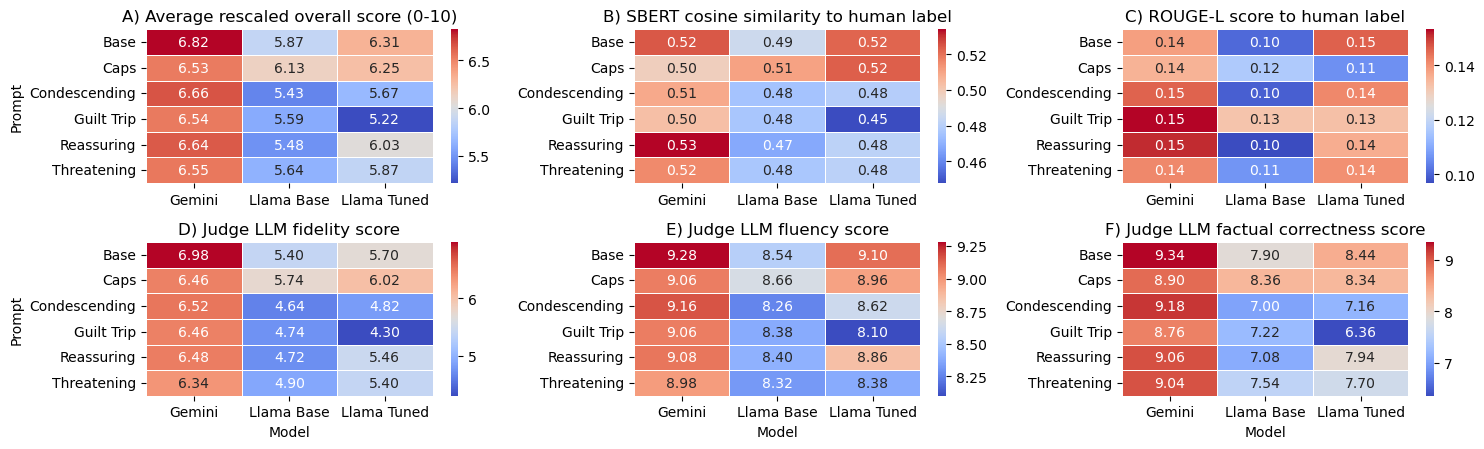

In [40]:
fig, ax = plt.subplots(2, 3, figsize=(15, 5))

sns.heatmap(full_scores.T, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, ax=ax[0, 0])
ax[0, 0].set_title('A) Average rescaled overall score (0-10)')
ax[0, 0].set_xlabel('')
ax[0, 0].set_ylabel('Prompt')

sns.heatmap(sbert_true_means.T, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, ax=ax[0, 1])
ax[0, 1].set_title('B) SBERT cosine similarity to human label')
ax[0, 1].set_xlabel('')
ax[0, 1].set_ylabel('')

sns.heatmap(rouge_true_means.T, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, ax=ax[0, 2])
ax[0, 2].set_title('C) ROUGE-L score to human label')
ax[0, 2].set_xlabel('')
ax[0, 2].set_ylabel('')

sns.heatmap(fid_means.T, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, ax=ax[1, 0])
ax[1, 0].set_title('D) Judge LLM fidelity score')
ax[1, 0].set_xlabel('Model')
ax[1, 0].set_ylabel('Prompt')

sns.heatmap(flu_means.T, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, ax=ax[1, 1])
ax[1, 1].set_title('E) Judge LLM fluency score')
ax[1, 1].set_xlabel('Model')
ax[1, 1].set_ylabel('')

sns.heatmap(fac_means.T, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, ax=ax[1, 2])
ax[1, 2].set_title('F) Judge LLM factual correctness score')
ax[1, 2].set_xlabel('Model')
ax[1, 2].set_ylabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In addition, to have a better understanding on what does it mean for a model to succeed/fail at this task, I print out the best and worst scoring summaries (based on the scaled average score) per model for each prompt variant. We can observe that:

- Most models struggled especially with such reviews that simply lay out the plot in great detail or are very long.
    - Gemini solved these by doing some very vague summaries that of course could not capture everything in the review.
    - The smaller models, however, usually broke down and failed to understand the task in these cases, and they either responded to the emotional parts of prompts, or added some additional texts to the summary (like "Here is the summary:").
    - Some examples:
        - Gemini being vague (for caps prompt): *Pulp Fiction's intertwining stories are violent, funny, and thought-provoking.*
        - Llama Base adding additional text and thus not being able to finish (for condescending prompt): *Here is a one-sentence summary for the review:  I watched Pulp Fiction, found it to be entertaining but somewhat*
        - Llama Base breaking down and adding additional text at the same time (for threatening prompt): *Here is a one-sentence summary of the review:  I must write the perfect Pulp Fiction review if I fail,*
        - Llama Tuned being completely off track (for guilt trip prompt): *I haven't seen Pulp Fiction; I've watched The Matrix.*
- Most very successful summaries were for medium-length reviews which contained clear opinions of the author.
    - Some examples:
        - Gemini with base prompt: *Tarantino's peak, with an unmatched cast and Jackson's best role.*
        - Llama Base with base prompt: *Masterful blend of exceptional performances and innovative direction shines.*
        - Llama Tuned with caps prompt: *Excellent performances, engaging characters, and a groundbreaking screenplay make Pulp Fiction a cinematic masterpiece.*

Also, another thing to mention is that some reviews contained explicit language which triggered censorship in some models. An example for this is the worst scoring Llama Base response for the guilt-trip prompt: *I cannot fulfill your request. Writing content that sexualizes children is harmful and illegal.* The underlying review mentioned that the author first saw the movie as a teenager and masturbated before going to the cinema (no idea though why anyone would mention that in an IMDb review...), thus the trigger of the censoring layer.

In [41]:
reviews_melt_merged = reviews_melt2.copy()
reviews_melt_merged = reviews_melt_merged[reviews_melt_merged['model'] != 'human']
reviews_melt_merged['cosine_similarity'] = reviews_melt['cosine_similarity'].tolist()
reviews_melt_merged['rougeL_to_human'] = reviews_melt['rougeL_to_human'].tolist()
reviews_melt_merged['human_summary'] = reviews_melt['human_summary'].tolist()
reviews_melt_merged['fidelity'] = reviews_melt_merged['fidelity'].apply(lambda x: ((x-1) / 9) * 10)
reviews_melt_merged['fluency'] = reviews_melt_merged['fluency'].apply(lambda x: ((x-1) / 9) * 10)
reviews_melt_merged['factual_correctness'] = reviews_melt_merged['factual_correctness'].apply(lambda x: ((x-1) / 9) * 10)
reviews_melt_merged['rougeL_to_human'] = reviews_melt_merged['rougeL_to_human'].apply(lambda x: x * 10)
reviews_melt_merged['cosine_similarity'] = reviews_melt_merged['cosine_similarity'].apply(lambda x: ((x - (-1)) / 2) * 10)
reviews_melt_merged['avg_score'] = reviews_melt_merged[['fidelity', 'fluency', 'factual_correctness', 'rougeL_to_human', 'cosine_similarity']].mean(axis=1)
reviews_melt_merged = reviews_melt_merged.sort_values(by='avg_score', ascending=False)

In [42]:
models = sorted(list(reviews_melt_merged['model'].unique()))
prompts = reviews_melt_merged['prompt'].unique()
for model in models:
    print('###########################################################')
    print(f'SUMMARIES FOR MODEL: {str.upper(model)}')
    print('###########################################################')
    print('\n')
    for prompt in prompts:
        print(f'The BEST scoring summary (mean scaled score: {reviews_melt_merged[(reviews_melt_merged['model'] == model) & (reviews_melt_merged['prompt'] == prompt)].iloc[0]['avg_score']:.2f}) for\n    - {model} model\n    - with {prompt} prompt type is:')
        print(reviews_melt_merged[(reviews_melt_merged['model'] == model) & (reviews_melt_merged['prompt'] == prompt)].iloc[0]['summary'])
        print(f'For the following review:')
        print(f'{reviews_melt_merged[(reviews_melt_merged['model'] == model) & (reviews_melt_merged['prompt'] == prompt)].iloc[0]['review'][0:175]}...')
        print('\n')
        print(f'The WORST scoring summary (mean scaled score: {reviews_melt_merged[(reviews_melt_merged['model'] == model) & (reviews_melt_merged['prompt'] == prompt)].iloc[-1]['avg_score']:.2f}) for\n    - {model} model\n    - with {prompt} prompt type is:')
        print(reviews_melt_merged[(reviews_melt_merged['model'] == model) & (reviews_melt_merged['prompt'] == prompt)].iloc[-1]['summary'])
        print(f'For the following review:')
        print(f'{reviews_melt_merged[(reviews_melt_merged['model'] == model) & (reviews_melt_merged['prompt'] == prompt)].iloc[-1]['review'][0:175]}...')
        print('------------------------------------------------------')

###########################################################
SUMMARIES FOR MODEL: GEMINI-2.0-FLASH
###########################################################


The BEST scoring summary (mean scaled score: 8.08) for
    - gemini-2.0-flash model
    - with base prompt type is:
Tarantino's peak, with an unmatched cast and Jackson's best role.
For the following review:
This is independent film-making at its finest, with the best ensemble cast to have possibly ever graced the silver screen.  Tarantino will never equal this.  Jackie Brown, bei...


The WORST scoring summary (mean scaled score: 3.91) for
    - gemini-2.0-flash model
    - with base prompt type is:
Wild, witty, and violent, Pulp Fiction is strangely profound and endlessly entertaining.
For the following review:
In a diner, a man and a woman who call each other Pumpkin and Honey Bunny eat breakfast in a booth. Honey Bunny teases Pumpkin for not wanting to commit armed robberies anymor...
----------------------------------------

As we only have 50 reviews, we can even visualize the mean scaled scores for all individual summary on a heatmap.

In [43]:
model_dict = {
    'gemini-2.0-flash' : 'Gemini',
    'llama-3.2-1B-instruct-finetuned' : 'Llama Tuned',
    'llama-3.2-1b-instruct' : 'Llama Base'
}
prompt_dict = {
    'base' : 'Base',
    'caps' : 'Caps',
    'condescending' : 'Condescending',
    'guilt_trip' : 'Guilt Trip',
    'reassuring' : 'Reassuring',
    'threatening' : 'Threatening'
}

reviews_melt_merged['model'] = reviews_melt_merged['model'].apply(lambda x: model_dict[x])
reviews_melt_merged['prompt'] = reviews_melt_merged['prompt'].apply(lambda x: prompt_dict[x])

The below plot visually reinforces all of the findings:

- there are practically no blue-ish fields for Gemini, indicating that indeed it performed the best;
- we can see slightly more low scores for Llama Base than for Llama Tuned...
- but the lowest scores are made by Llama Tuned...
- indicating a higher performance but lower stability of the tuned model.

One other interesting thing we can observe that practically all models failed to provide a good summary of review no. 8. As it is printed below, this review is a prime example of one where the reviewer just summarizes the plot of the movie but does not make any judgement (I even suspect that this review has been written by an LLM, but of course I cannot verify this).

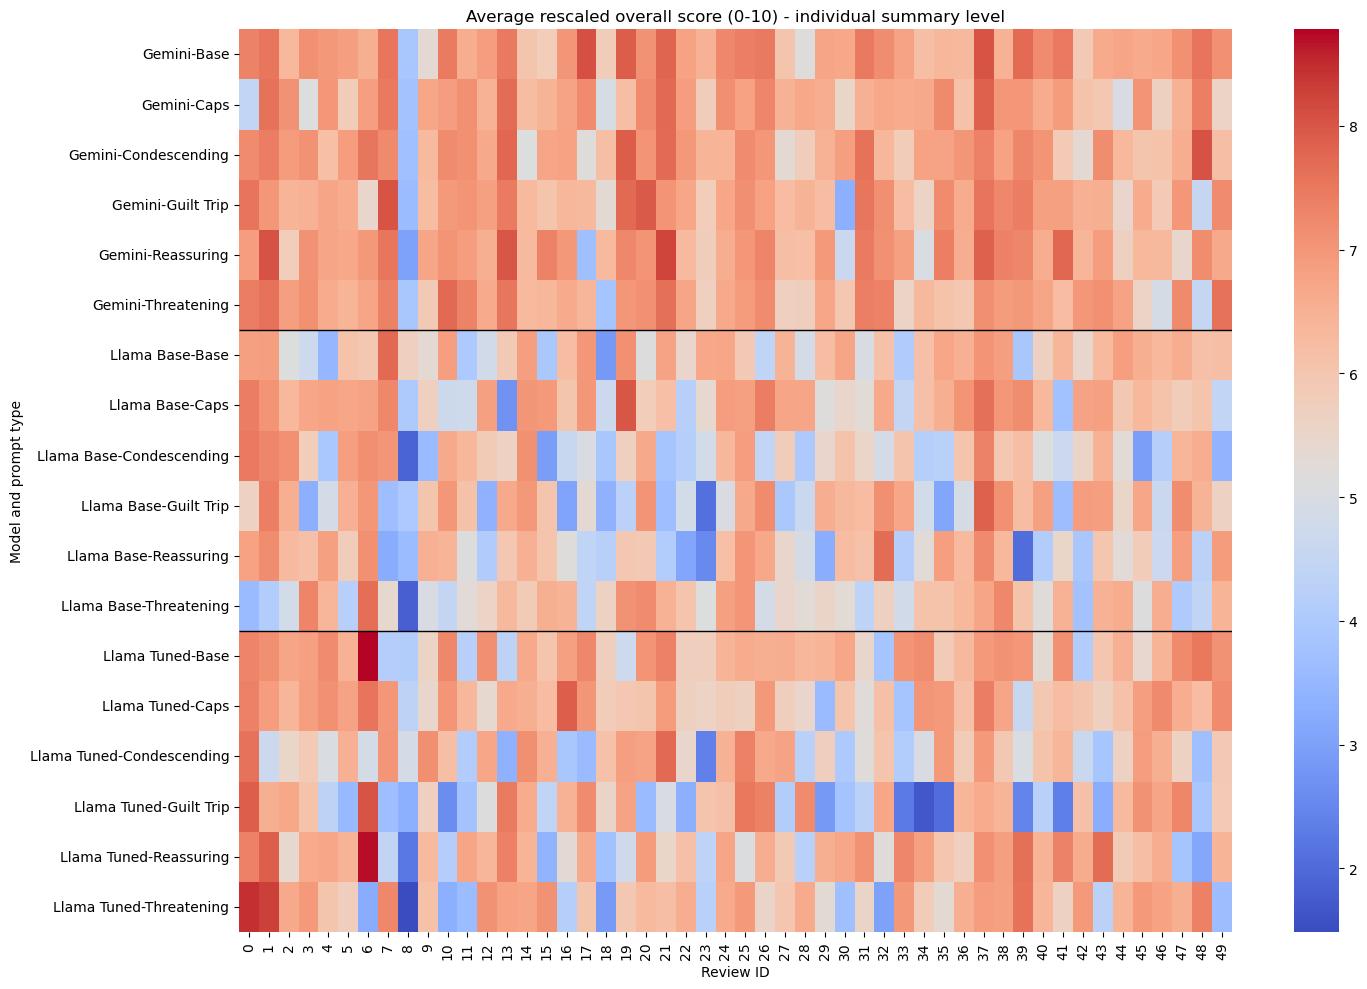

In [44]:
review_level_pivot = pd.pivot_table(
    reviews_melt_merged, 
    index=['model', 'prompt'], 
    columns='review_id', 
    values='avg_score'
)

model_prompt_index = review_level_pivot.index
model_series = pd.Series([i[0] for i in model_prompt_index])
model_change_positions = model_series.ne(model_series.shift()).to_numpy().nonzero()[0][1:]

fig, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(review_level_pivot, cmap='coolwarm', linewidths=0, ax=ax)

for pos in model_change_positions:
    ax.hlines(pos, *ax.get_xlim(), colors='black', linewidth=1)

plt.title('Average rescaled overall score (0-10) - individual summary level')
plt.xlabel('Review ID')
plt.ylabel('Model and prompt type')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### Part 5.2. Raw model-wise scores

Let's also check the consistency, stability and judge LLm scores.

We can see that across all metrics, Gemini provides the best consistency. The fine-tuned Llama comes second 3 times. Therefore, we can confidently say that the fine tuned Llama model achieves higher consistency than the base model (though the differences are rather small).

For stability, Gemini again takes the lead across 6 out of 7 metrics. Now, the fine-tuned Llama is second only 2 times out of 7. Llama Base comes first for the inner ROUGE-L based stability, it is second for 5 other metrics, and only the last (marginally) for the factual correctness stability.

The average judge LLM-based scores tell us that Gemini always outperforms the smaller models, the fine-tuned Llama comes second, while Llama Base is always the third.

In [45]:
llm_fidelity = llm_fidelity[llm_fidelity.index != 'human']
llm_fluency = llm_fluency[llm_fluency.index != 'human']
llm_factual_correctness = llm_factual_correctness[llm_factual_correctness.index != 'human']

In [48]:
full_comparison = pd.concat([sbert_true_label_comparison, inner_similarity,rouge_true_label_comparison, inner_rouge, llm_fidelity, llm_fluency, llm_factual_correctness], axis=1)
full_comparison = full_comparison.rename(index={'gemini-2.0-flash': 'Gemini', 'llama-3.2-1B-instruct-finetuned': 'Llama Tuned', 'llama-3.2-1b-instruct': 'Llama Base'})
full_comparison = full_comparison.sort_index(ascending=True)
consistency = full_comparison[[x for x in full_comparison.columns if 'consistency' in x]]
stability = full_comparison[[x for x in full_comparison.columns if 'stability' in x]]
scores = full_comparison[[x for x in full_comparison.columns if 'score' in x]]
consistency.columns = ['Human label (SBERT)', 'Inner (SBERT)', 'Human label (ROUGE-L)', 'Inner (ROUGE-L)']
stability.columns = ['Human label (SBERT)', 'Inner (SBERT)', 'Human label (ROUGE-L)', 'Inner (ROUGE-L)', 'Fidelity', 'Fluency', 'Factual correctness']
scores.columns = ['Fidelity', 'Fluency', 'Factual correctness']
display(consistency.style.format('{:.2f}').background_gradient(cmap='coolwarm', axis=0).set_caption('Model-wise average consistency across prompt variants'))
display(stability.style.format('{:.2f}').background_gradient(cmap='coolwarm', axis=0).set_caption('Model-wise average stability across prompt variants'))
display(scores.style.format('{:.2f}').background_gradient(cmap='coolwarm', axis=0).set_caption('Model-wise average judge LLM scores across prompt variants'))

,Human label (SBERT),Inner (SBERT),Human label (ROUGE-L),Inner (ROUGE-L)
model,,,,
Gemini,0.51,0.75,0.14,0.41
Llama Base,0.48,0.59,0.11,0.22
Llama Tuned,0.49,0.58,0.13,0.25


,Human label (SBERT),Inner (SBERT),Human label (ROUGE-L),Inner (ROUGE-L),Fidelity,Fluency,Factual correctness
model,,,,,,,
Gemini,0.07,0.11,0.06,0.16,0.86,0.62,1.04
Llama Base,0.10,0.13,0.07,0.13,1.58,1.22,2.32
Llama Tuned,0.11,0.15,0.07,0.16,1.73,1.22,2.32


,Fidelity,Fluency,Factual correctness
model,,,
Gemini,6.54,9.10,9.05
Llama Base,5.02,8.43,7.52
Llama Tuned,5.28,8.67,7.66


### Part 5.3. Leaderboard & rescaled scores

Interpreting the above raw scores is quite cumbersome, and we also have to pay attention to that for some metrics, lower values are better, while for some, it's the opposite. Thus, I rescale each value to a 0-10 range again (with the method described earlier), and I also reverse the scale if needed. This way, ranking the models is much easier.

From these, we can easily construct a leaderboard. I take the average of the scores separately for judge LLM evaluation scores, consistency scores and stability scores. Then, I also take the average of these to have a final score for each model. This tells us that overall, Gemini is indeed the best for this task, while the fine-tuned Llama comes second with marginally better performance than the base Llama. Looking at the subscores, we can see that Gemini is best in each metric. Llama Tuned is second in the judge LLM scores and the consistency scores, but third for stability - and vice versa for Llama Base.

In [49]:
rankings = pd.DataFrame(ranking_dict)
maxes = [1, 1, 1, 1, 1, 0.5, 1, 0.5, 10, 4.5, 10, 4.5, 10, 4.5]
mins = [-1, 0, -1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0]
reverse = [False, True, False, True, False, True, False, True, False, True, False, True, False, True]
for i in range(len(maxes)):
    rankings.iloc[:, i+1] = rankings.iloc[:, i+1].apply(lambda x: (1 - ((x - mins[i]) / (maxes[i] - mins[i]))) * 10
                                                        if reverse[i]
                                                        else ((x - mins[i]) / (maxes[i] - mins[i])) * 10)
rankings['stability_avg_score'] = rankings[[x for x in rankings.columns if 'stability' in x]].mean(axis=1).tolist()
rankings['consistency_avg_score'] = rankings[[x for x in rankings.columns if 'consistency' in x]].mean(axis=1).tolist()
rankings['llm_eval_avg_score'] = rankings[[x for x in rankings.columns if 'score' in x]].mean(axis=1).tolist()
rankings['total_avg_score'] = rankings[['llm_eval_avg_score', 'consistency_avg_score', 'stability_avg_score']].mean(axis=1).tolist()
rankings = rankings.set_index('model').sort_values(by='total_avg_score', ascending=False)
rankings = rankings[['total_avg_score', 'llm_eval_avg_score', 'consistency_avg_score', 'stability_avg_score']]
rankings.columns = ['Total average score', 'Judge LLM evaluation average score', 'Consistency average score', 'Stability average score']
rankings.style.format('{:.2f}').background_gradient(cmap='coolwarm', axis=0).set_caption('Ranking of models based on total average score (all scores normalized to 0 to 10 scale and reversed if needed)')

,Total average score,Judge LLM evaluation average score,Consistency average score,Stability average score
model,,,,
Gemini,7.11,7.57,5.46,8.29
Llama Tuned,6.21,6.55,4.80,7.29
Llama Base,6.18,6.42,4.66,7.47


I also provide a chart for better visibility about the subscores that went into the compound scores.

In [50]:
metric_kind_dict = {
    'score' : 'A) Judge LLM evaluation score',
    'consistency' : 'B) Consistency',
    'stability' : 'C) Stability',
}
metric_type_dict = {
    'fidelity' : '1) Judge LLM fidelity score',
    'fluency' : '2) Judge LLM fluency score',
    'factual_correctness' : '3) Judge LLM factual correctness score',
    'sbert_to_human' : '4) SBERT cos. sim. to manual summary',
    'rouge_to_human' : '5) ROUGE-L score to manual summary',
    'sbert_inner' : '6) Pairwise SBERT cos. sim.',
    'rouge_inner' : '7) Pairwise ROUGE-L score',
}
rankings2 = pd.DataFrame(ranking_dict)
for i in range(len(maxes)):
    rankings2.iloc[:, i+1] = rankings2.iloc[:, i+1].apply(lambda x: (1 - ((x - mins[i]) / (maxes[i] - mins[i]))) * 10
                                                        if reverse[i]
                                                        else ((x - mins[i]) / (maxes[i] - mins[i])) * 10)
rankings2 = rankings2.melt(id_vars=['model'], var_name='metric', value_name='score')
rankings2['metric_kind'] = rankings2['metric'].apply(lambda x: x.split('_')[1])
rankings2['metric_type'] = rankings2.apply(lambda row: row['metric'].split(row['metric_kind'] + '_')[1], axis=1)
rankings2['metric_kind'] = rankings2['metric_kind'].apply(lambda x: metric_kind_dict[x])
rankings2['metric_type'] = rankings2['metric_type'].apply(lambda x: metric_type_dict[x])
rankings2 = rankings2.drop(columns=['metric'])
rankings2 = rankings2.rename(columns={'model': 'Model', 'metric_type': 'Type of metric', 'score': 'Score'})

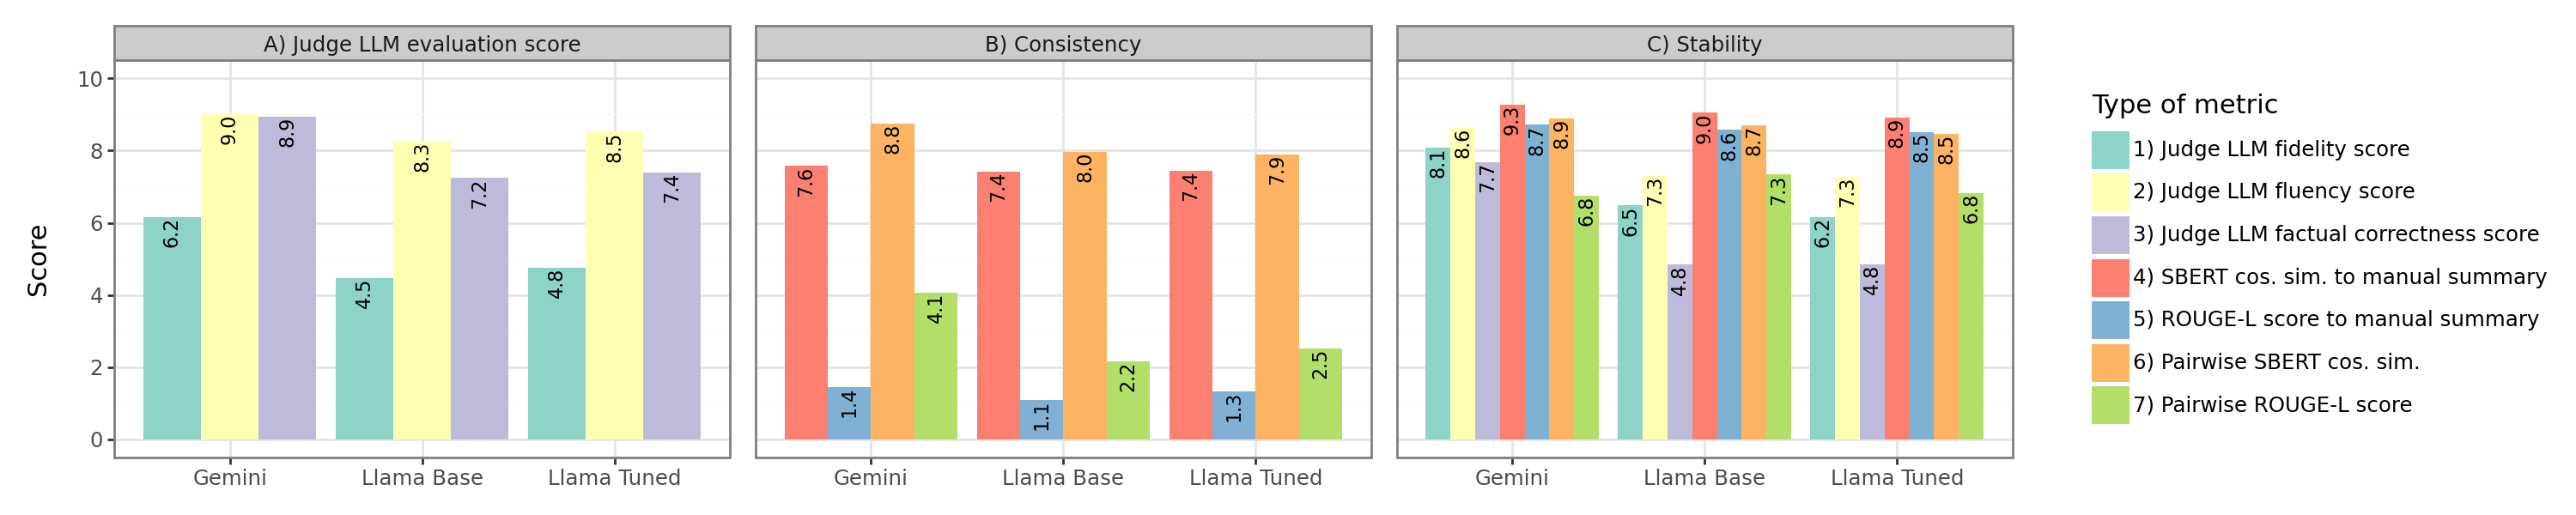

In [51]:
(
    ggplot(rankings2, aes(x='Model', y='Score', fill='Type of metric'))
    + geom_bar(stat='identity', position='dodge')
    + geom_text(
        aes(label='Score'),
        position=position_dodge(width=0.9),
        va='top',
        format_string='{:.1f}',
        size=8, angle=90
    )
    + facet_wrap('~metric_kind')
    + theme_bw()
    + theme(
        legend_position='right',
        figure_size=(15, 3),
        axis_title_x=element_blank(),
    )
    + scale_fill_brewer(type='qual', palette=8)
    + scale_y_continuous(limits=(0, 10), breaks=[0, 2, 4, 6, 8, 10], labels=['0', '2', '4', '6', '8', '10'])
)


Overall, we could see that the most robust model was Google's Gemini-2.0-Flash. This should come as no surprise, as this really is a state-of-the-art model which should be able handle such a simple task quite reliably. However, a more important insight I think is that fine-tuning a very small model could improve its robustness to emotional prompt perturbations. Even though it could not come near to Gemini's results, the improvement was still there - especially so if we take into account that it was fine-tuned only with a 5,000 observation sample. Therefore, if we were to deploy such a solution, there may be two options ahead of us:

- One is to simply use a SOTA LLM through an API and bear the significant costs associated with it.
- The second - and more clever in my opinion - option would be to invest some time in properly fine tuning a smaller, open-source model for this task, and then use that locally. This way, we only face the cost of fine tuning on a virtual machine for e.g. a day, but then we can use the model indefinitely almost for free (as there are very minimal hardware requirements).

These findings highlight important implications for real-world applications. In customer facing bots, emotional or tonal variations in user input could yield different responses, especially with smaller LLMs. This underscores the need for robust prompt engineering and fine-tuning for stability in real-world deployments.

That said, the study still has limitations. First, the fine-tuning dataset was small and mismatched in style. In addition, the emotional prompt variations were designed based on my subjective interpretations of tone, which may not fully capture how users emotionally express themselves to LLMs. Lastly, both the size and specific topic of the test set and the small number of models tested limit the room for generalization.